# VOYAGER LISM EDA

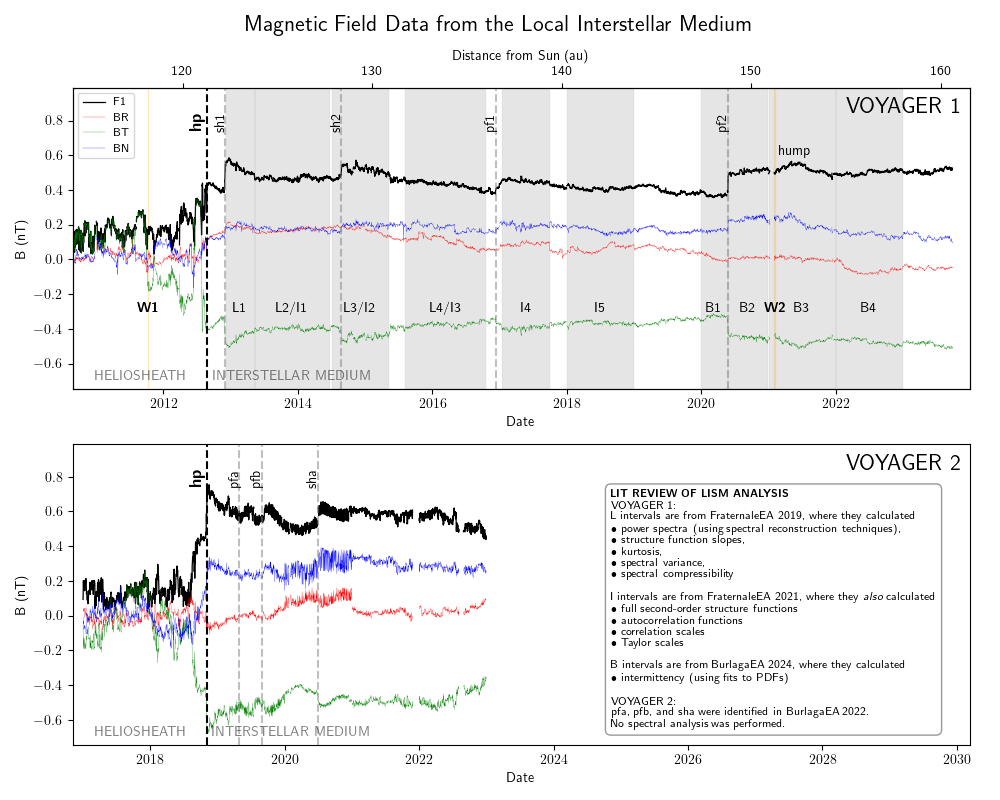

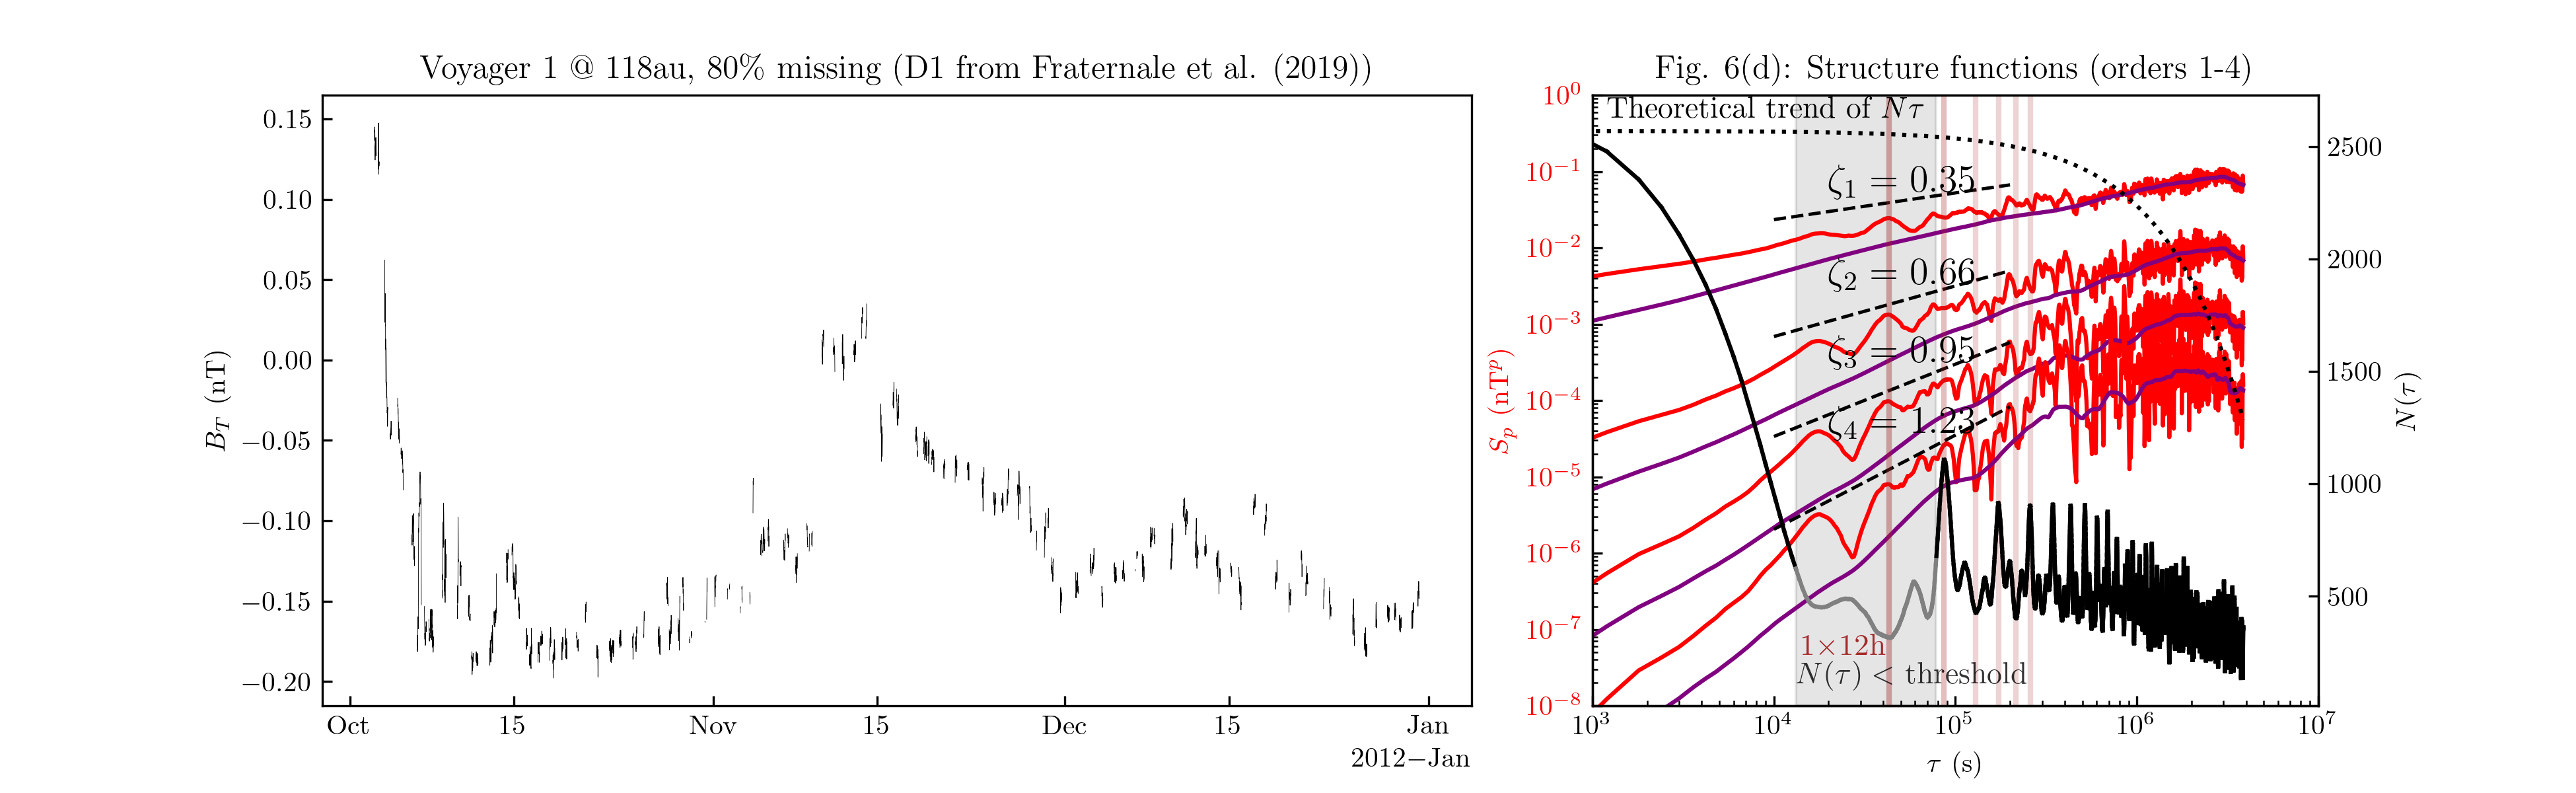

# Outlier searching

In [141]:
import numpy as np
import pandas as pd
import math as m
import pickle
from matplotlib import pyplot as plt
from matplotlib import gridspec
import matplotlib.dates as mdates
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sunpy.timeseries import TimeSeries
from matplotlib.dates import DateFormatter

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"


import sys
import os
import glob

sys.path.append(os.path.abspath(".."))
# So that I can read in the src files while working here in the notebooks/ folder
# NB: does not affect working directory, so still need ../data e.g. for reading data

import src.utils as utils
import src.params as params
import src.sf_funcs as sf

### Define funcs

In [157]:
# Function to identify separate groups of adjacent outliers
def identify_outlier_groups(outliers_series, max_gap="1h"):
    """
    Identify groups of adjacent outliers with gaps no larger than max_gap.
    Returns a list of DataFrames, each containing a group of outliers.
    """
    if outliers_series.empty:
        return []

    # Convert to DataFrame for easier manipulation
    outliers_df = outliers_series.reset_index()
    outliers_df.columns = ["timestamp", "value"]

    # Sort by timestamp
    outliers_df = outliers_df.sort_values("timestamp")

    # Initialize groups
    groups = []
    current_group = [outliers_df.iloc[0]]

    # Group adjacent outliers
    for i in range(1, len(outliers_df)):
        current_time = outliers_df.iloc[i]["timestamp"]
        previous_time = current_group[-1]["timestamp"]

        # Check if the gap between current and previous point is small enough
        if current_time - previous_time <= pd.Timedelta(max_gap):
            # Add to current group
            current_group.append(outliers_df.iloc[i])
        else:
            # Start a new group
            groups.append(pd.DataFrame(current_group))
            current_group = [outliers_df.iloc[i]]

    # Add the last group
    if current_group:
        groups.append(pd.DataFrame(current_group))

    return groups

In [149]:
threshold = 17
window_size = 3000


# Function to detect outliers using Hampel filter
def detect_outliers(
    series, window_size=window_size, threshold=threshold, min_mad=0.002
):
    # Compute the rolling median
    rolling_median = series.rolling(window=window_size, min_periods=1).median()

    # Use this pattern when possible:
    rolling_abs_dev = np.abs(series - rolling_median)
    rolling_mad = rolling_abs_dev.rolling(window=window_size, min_periods=1).median()

    # Apply minimum MAD threshold
    rolling_mad = np.maximum(rolling_mad, min_mad)

    rolling_kurt = series.rolling(window=100, min_periods=1).kurt()

    # Calculate deviation scores
    deviation_scores = np.fabs(series - rolling_median) / rolling_mad

    # Identify outliers
    outliers = series[deviation_scores > threshold]

    # Compute the rolling fraction of missing data over a window of one week
    rolling_missing = series.isna().rolling(window="24h", min_periods=1).mean()

    return outliers, rolling_median, rolling_mad, rolling_kurt, rolling_missing

In [ ]:
# Example of calibration roll
#plt.plot(df["2013-01-01 22:00":"2013-01-02 02:00"])
# plt.xticks(rotation=45)
# plt.legend()

## Hampel filter

In [167]:
spacecraft = "voyager1"
year = "2013"

data = TimeSeries(
    f"../data/raw/{spacecraft}_48s_mag-vim_{year}0101_v01_OLD.cdf",
    concatenate=True,  # Not strictly relevant here as only reading one file at a time
)
# data.columns
# data.units
# data.time_range

df_raw = data.to_dataframe()
df_raw

,BN,BR,BT,F1,dBN,dBR,dBT,dF,spacecraftID,Radius,hg_lat,hg_lon,hgi_lon
2013-01-01 00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122.849998,34.5,116.5,174.199997
2013-01-01 00:00:32.832,0.17658,0.20105,-0.49242,0.56044,0.1,0.02,0.02,0.02,1.0,NaN,NaN,NaN,NaN
2013-01-01 00:01:21.215,0.17539,0.19999,-0.49560,0.56249,0.1,0.02,0.02,0.02,1.0,NaN,NaN,NaN,NaN
2013-01-01 00:02:08.735,0.17144,0.19585,-0.49851,0.56238,0.1,0.02,0.02,0.02,1.0,NaN,NaN,NaN,NaN
2013-01-01 00:02:57.120,0.17237,0.20250,-0.50149,0.56767,0.1,0.02,0.02,0.02,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31 06:16:25.824,0.17888,0.17077,-0.38468,0.45735,0.1,0.02,0.02,0.02,1.0,NaN,NaN,NaN,NaN
2013-12-31 06:17:13.343,0.18424,0.17686,-0.38925,0.46557,0.1,0.02,0.02,0.02,1.0,NaN,NaN,NaN,NaN
2013-12-31 06:18:00.864,0.18246,0.17415,-0.38236,0.45813,0.1,0.02,0.02,0.02,1.0,NaN,NaN,NaN,NaN
2013-12-31 06:18:50.975,0.18652,0.17574,-0.38141,0.45954,0.1,0.02,0.02,0.02,1.0,NaN,NaN,NaN,NaN


In [164]:
df = df_raw[["BN", "BR", "BT", "F1"]]
df = df.resample("48s").mean()

In [165]:
# Detect outliers for each compoment, then combine

outliers = {}
rolling_median = {}
rolling_mad = {}
rolling_kurt = {}
rolling_missing = {}

components = df.columns
for component in components:
    outliers[component], rolling_median[component], rolling_mad[component], rolling_kurt[component], rolling_missing[component] = detect_outliers(df[component])

# Combine the timestamps for all outliers
all_outlier_times = pd.concat(outliers.values()).sort_index().index

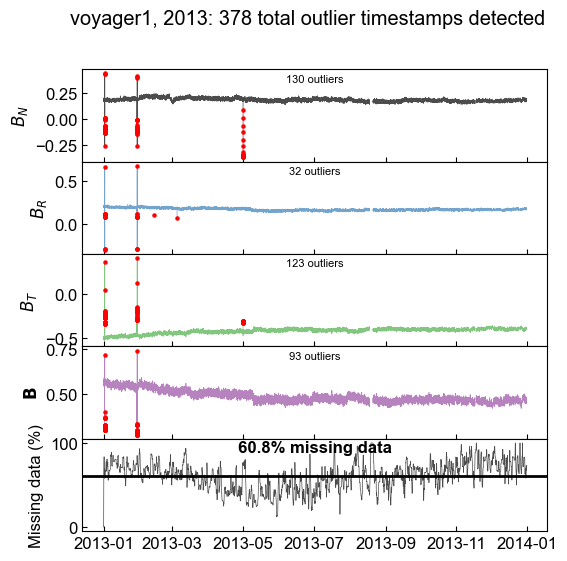

In [188]:
fig, ax = plt.subplots(len(components)+1, 1, figsize=(6, 6), sharex=True)
plt.subplots_adjust(hspace=0)  # Remove white space between subplots

labels = {"BN": "$B_N$", "BR": "$B_R$", "BT": "$B_T$", "F1": "$\\mathbf{B}$"}

colors = [ "black", "#377eb8", "#4daf4a", "#984ea3"]


# Iterate through each component and its corresponding subplot
for i, (comp, color) in enumerate(zip(components, colors)):
    ax[i].plot(df[comp], label=labels[comp], lw=0.5, color=color, alpha=0.7, zorder=1)

    # Annotate with number of outliers detected for each component
    ax[i].text(
        0.5,
        0.95,
        f"{len(outliers[comp])} outliers",
        transform=ax[i].transAxes,
        fontsize=8,
        verticalalignment="top",
        horizontalalignment="center",
    )

    ax[i].scatter(
        outliers[comp].index,
        outliers[comp],
        color="red",
        label="Outliers",
        marker="o",
        s=5,
        zorder=2,
    )

    ax[i].set_ylabel(f"{labels[comp]}")

overall_missing = df['BN'].isna().sum() / len(df['BN'])*100

# Plot the rolling fraction of missing data
ax[-1].plot(rolling_missing[components[0]]*100, color="black", lw=0.5, alpha=0.7)
ax[-1].axhline(overall_missing, color="black", lw=2, label="Overall missing data")
# Annotate with overall missing data percentage
ax[-1].text(
    0.5,
    0.85,
    f"{overall_missing:.1f}% missing data",
    transform=ax[-1].transAxes,
    weight="bold",
    horizontalalignment="center",
)
ax[-1].set_ylabel("Missing data (%)")
# Put number of outliers detected in title
fig.suptitle(
    f"{spacecraft}, {year}: {len(all_outlier_times)} total outlier timestamps detected",
)

# plt.savefig(f"../results/cleaning/outliers_{spacecraft}_{year}.png", dpi=300)
plt.show()

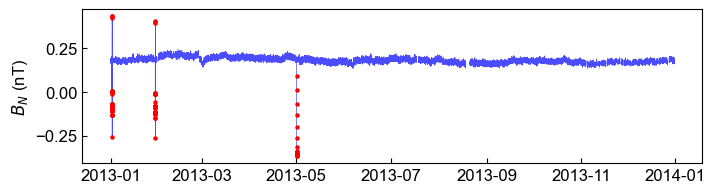

In [203]:
# Plot only BN and the missing-data subplot
comp = "BN"
fig, ax = plt.subplots(figsize=(8, 2), sharex=True)
plt.subplots_adjust(hspace=0.05)

color = colors[0]

# Main BN time series with outliers
ax.plot(df[comp], label="$B_N$", lw=0.5, color="blue", alpha=0.7, zorder=1)
# ax.text(
#     0.5,
#     0.95,
#     f"{len(outliers[comp])} outliers detected",
#     transform=ax.transAxes,
#     fontsize=8,
#     verticalalignment="top",
#     horizontalalignment="center",
# )
ax.scatter(
    outliers[comp].index,
    outliers[comp],
    color="red",
    label="Outliers",
    marker="o",
    s=5,
    zorder=2,
)
ax.set_ylabel("$B_N$ (nT)")
# ax.legend(fontsize=8, loc="upper left")

# # Missing-data fraction subplot
# overall_missing = df[comp].isna().sum() / len(df[comp]) * 100
# ax[1].plot(rolling_missing[comp] * 100, color="black", lw=0.5, alpha=0.7)
# ax[1].axhline(overall_missing, color="black", lw=2, label="Overall missing data")
# ax[1].text(
#     0.5,
#     0.85,
#     f"{overall_missing:.1f}% missing data",
#     transform=ax[1].transAxes,
#     weight="bold",
#     horizontalalignment="center",
# )
# ax[1].set_ylabel("Missing data (%)")

# fig.suptitle(
#     f"{spacecraft}, {year}: {len(all_outlier_times)} total outlier timestamps detected"
# )

plt.savefig(f"../results/cleaning/outliers_{spacecraft}_{year}_BN_only.png", dpi=300)


NB: takes way longer with time indices - but probably need these for outlier plotting? What does the outlier dataset look like? Can we just plot it without time indices? This would need it to have the same length as the original dataset...

### Plot individual outliers groups for a specific component

In [162]:
comp = "BN"

# Identify groups of adjacent outliers
outlier_groups = identify_outlier_groups(
    outliers[comp], max_gap="2h"
)  # Adjust max_gap as needed

print(f"Found {len(outlier_groups)} distinct outlier groups in {comp}")

Found 3 distinct outlier groups in BN


C:\Users\spann\AppData\Local\Temp\ipykernel_11828\2203146775.py:89: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.18)
C:\Users\spann\AppData\Local\Temp\ipykernel_11828\2203146775.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



Outlier groups summary:
Group 1: January 2013, 55 outliers, duration: 0 days 02:43:12, starting at 2013-01-01 22:18
Group 2: January 2013, 45 outliers, duration: 0 days 02:43:12, starting at 2013-01-29 20:42
Group 3: May 2013, 30 outliers, duration: 0 days 00:23:12, starting at 2013-05-01 05:10


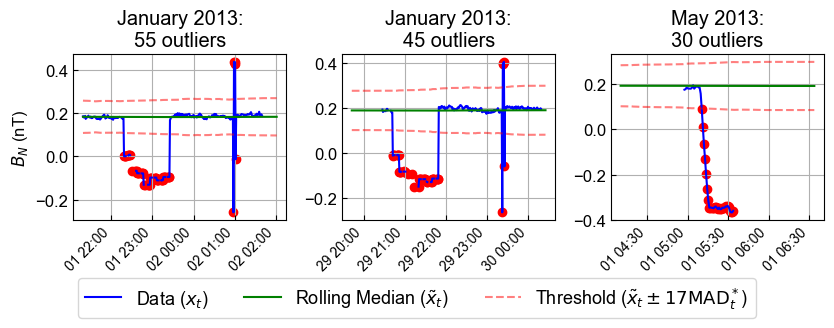

In [211]:
# Create a figure with subplots for each outlier group
if outlier_groups:
    # Create a grid of subplots (max 3 per row)
    n_groups = len(outlier_groups)
    n_cols = min(3, n_groups)  # Max 3 columns
    n_rows = (n_groups + n_cols - 1) // n_cols  # Ceiling division

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(8.5, 3), constrained_layout=True
    )

    # Make axes indexable even if there's only one subplot
    if n_groups == 1:
        axes = np.array([axes])

    # Flatten axes array for easier indexing
    axes = np.array(axes).reshape(-1)

    # Format for the dates on x-axis
    date_format = DateFormatter("%d %H:%M")

    for i, group in enumerate(outlier_groups):
        if i >= len(axes):
            break

        # Get the first and last timestamp of the group
        first_timestamp = group["timestamp"].min()
        last_timestamp = group["timestamp"].max()

        # Get the surrounding 12 hours of data
        start_time = first_timestamp - pd.Timedelta(hours=1)
        end_time = last_timestamp + pd.Timedelta(hours=1)

        # Get window data
        window_data = df[comp][start_time:end_time]
        window_median = rolling_median[comp][start_time:end_time]

        # Plot the window data
        ax = axes[i]
        ax.plot(window_data.index, window_data.values, "b-", label="Data ($x_t$)")
        ax.plot(
            window_median.index,
            window_median.values,
            "g-",
            label="Rolling Median ($\\tilde{x}_t$)",
        )

        # Highlight all outliers in the group
        for timestamp in group["timestamp"]:
            ax.scatter(
                timestamp,
                df[comp].loc[timestamp],
                color="red",
                marker="o",
            )

        # Add threshold lines
        window_mad = rolling_mad[comp][start_time:end_time]
        upper_bound = window_median + threshold * window_mad
        lower_bound = window_median - threshold * window_mad
        ax.plot(
            upper_bound.index,
            upper_bound.values,
            "r--",
            alpha=0.5,
            label=f"Threshold ($\\tilde{{x}}_t \\pm {threshold}\\text{{MAD}}_t^*$)",
        )
        ax.plot(lower_bound.index, lower_bound.values, "r--", alpha=0.5)

        # Format the plot
        ax.xaxis.set_major_formatter(date_format)
        month_name = first_timestamp.strftime("%B %Y")
        n_points_in_group = len(group)
        ax.set_title(
            f'{month_name}:\n{n_points_in_group} outlier{"s" if n_points_in_group > 1 else ""}'
        )
        ax.grid(True)

        # Rotate x-axis labels for better readability
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Place a single legend centered below the figure (3 columns, fontsize 12)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=13, bbox_to_anchor=(0.5, -0.12))
    plt.subplots_adjust(bottom=0.18)
    axes[0].set_ylabel("$B_N$ (nT)")
    plt.tight_layout()
    # plt.subplots_adjust(top=0.95)
    plt.savefig(f"../results/cleaning/outliers_{spacecraft}_{year}_groups_{comp}.png", dpi=300, bbox_inches='tight')
    # plt.show()

    # Print summary information
    print("\nOutlier groups summary:")
    for i, group_df in enumerate(outlier_groups):
        first_time = group_df["timestamp"].min()
        month_name = first_time.strftime("%B %Y")
        n_points = len(group_df)
        duration = group_df["timestamp"].max() - group_df["timestamp"].min()
        print(
            f"Group {i+1}: {month_name}, {n_points} outlier{'s' if n_points > 1 else ''}, "
            f"duration: {duration}, starting at {first_time.strftime('%Y-%m-%d %H:%M')}"
        )
else:
    print("No outliers found in the dataset.")

## Plot the biggest lag-1 increments

In [ ]:
diffs = df[component].diff()

# Plot the 12hours around the top n most extreme differences
n = 50
time_window = pd.DateOffset(hours=3)

top_diffs = diffs.abs().nlargest(n)

fig, ax = plt.subplots(10, 5, figsize=(12, 16))
ax = ax.flatten()
for i, date in enumerate(top_diffs.index):
    ax[i].plot(df[date - time_window : date + time_window][component], alpha=0.5)
    ax[i].axvline(date, color="black", linestyle="--", alpha=0.5)
    ax[i].scatter(
        outliers[comp][date - time_window : date + time_window].index,
        outliers[comp][date - time_window : date + time_window],
        color="red",
        label="Outliers",
        marker="o",
        # Change the marker size
        s=4,
    )
    ax[i].annotate(
        f"{date.strftime('%Y-%m-%d')}: {top_diffs[date]:.2f}",
        (0.1, 0.9),
        xycoords="axes fraction",
        ha="left",
        va="center",
        fontsize=8
    )
    # Remove axis tickmarks
    ax[i].set_xticks([])
    # ax[i].set_yticks([])
    # plt.legend()
    # plt.title(f"Outliers around {date.strftime('%Y-%m-%d %H:%M:%S')}")
plt.suptitle(f"Top {n} largest (lag 1) differences in $B_N$")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
sys.exit()

SystemExit: 

c:\Users\spann\Documents\Research\Code repos\sf_gap_analysis\venv\lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Interative plot with kurtosis

In [ ]:
fig = make_subplots(
    rows=len(components),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    specs=[[{"secondary_y": True}] for _ in components],
    # template="plotly_white",
)

# Iterate through each component and its corresponding subplot
for i, (comp, color) in enumerate(zip(components, colors)):
    fig.add_trace(
        go.Scatter(
            x=df[comp].index,
            y=df[comp],
            mode="lines",
            name=labels[comp],
            line=dict(width=1, color=color),
        ),
        row=i + 1,
        col=1,
        secondary_y=False,
    )
    fig.add_trace(
        go.Scatter(
            x=rolling_kurt[comp].index,
            y=rolling_kurt[comp],
            mode="lines",
            name=f"{labels[comp]} Rolling Kurtosis",
            line=dict(width=0.8, color="#ff7f00"),
            yaxis=f"y{i+1}",
        ),
        row=i + 1,
        col=1,
        secondary_y=True,
    )

    fig.update_yaxes(
        title_text=comp,
        row=i + 1,
        col=1,
        secondary_y=False,
        title_font=dict(color=color),
    )


# Add vertical lines spanning all subplots
for outlier_time in all_outlier_times:
    fig.add_shape(
        go.layout.Shape(
            type="line",
            x0=outlier_time,
            x1=outlier_time,
            y0=0,
            y1=1,
            xref="x",
            yref="paper",
            line=dict(color="red", width=1.5),
        )
    )


fig.update_yaxes(
    title_text="100-pt Rolling Kurtosis",
    row=1,
    col=1,
    secondary_y=True,
    title_font=dict(color="#ff7f00"),
)
fig.update_layout(
    height=600,
    width=1200,
    title_text="LISM Mag Field with Hampel-Filtered Outliers and Rolling Kurtosis",
    showlegend=False,
    template="simple_white",
)
fig.show()

## Computing correlation scale

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2732400 entries, 2018-11-05 00:00:00 to 2022-12-31 23:59:12
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 62.5 MB


In [ ]:
df_daily = df.resample("1D").mean()

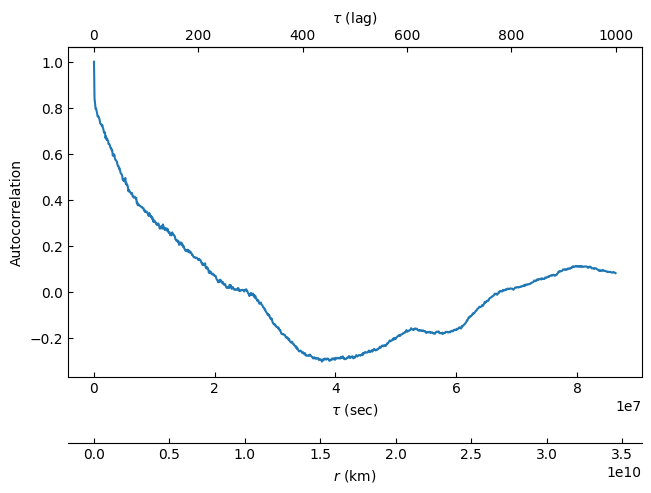

Correlation time = 7989457.0s = 2219.0 hours


In [ ]:
time_lags_lr, r_vec_lr = utils.compute_nd_acf(
    [df_daily.BR, df_daily.BT, df_daily.BN],
    nlags=1000,  # Arbritrary large number
    plot=True,
)
tc_exp = utils.compute_outer_scale_exp_trick(time_lags_lr, r_vec_lr, plot=False)
# Plot horizontal line at 1/e
#plt.axhline(1/np.e, color="red", linestyle="--", label="1/e")

print(f"Correlation time = {np.round(tc_exp)}s = {np.round(tc_exp/3600)} hours")

In [ ]:
2219/24

92.45833333333333

Calculating correlation time, using full 60-day dataset. Note highly wiggly ACF due to gaps. 

Also calculating $\lambda_C$ using integral method

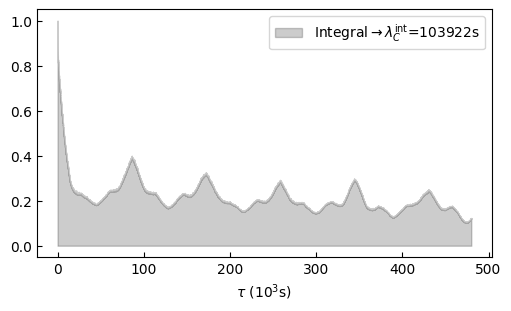

28.867149018499074
hours


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
tc, fig, ax = utils.compute_outer_scale_integral(time_lags_lr, r_vec_lr, fig, ax, True)
# print(f"Correlation time = {np.round(tc)}s = {np.round(tc/3600)} hours")

plt.show()
print(tc / 60 / 60)
print("hours")

In [ ]:
print(
    "10 of these is ",
    np.round(10 * tc / 60 / 60 / 24, 2),
    "days, compared with full data length of",
    df.index[-1] - df.index[0],
)

10 of these is  12.03 days, compared with full data length of 364 days 00:00:00


Note that this integral version is much longer, which will make the final interval lengths *slightly* more comparable with Fraternale's ints. (But note in either case the underlying ACF does look a bit silly)

#### Issues with comparing results

##### Complete SFs

- We are simplifying by down-sampling for ease of time, and approximating B_parallel with B_T

##### Corrected SFs
- We are computing vector SFs. Not only is not the same as them, but it also complicates the picture of re-scaling back to the original units. Chen (2012) work with normalised SFs may possibly help here.
- Not yet shown here, but below we perform our de-biasing of an interpolated version of this interval (shown by purple SFs). However, the correction factor is trained on 10 correlation lengths worth of data, with the SF calculated up to 2 $\lambda_C$, which, as shown by the vertical blue lines above, is much shorter than their intervals. 

# Gap distribution analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Union, Tuple
from matplotlib.ticker import FuncFormatter

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="Arial", size=12)


# Read in cleaned voyager data
# df = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
df_v1 = pd.read_pickle("../data/interim/voyager/voyager1_lism.pkl")
# Remove missing portion from the end
df_v1 = df_v1.loc[: df_v1.last_valid_index()]

df_v2 = pd.read_pickle("../data/interim/voyager/voyager2_lism.pkl")
df_v2 = df_v2.loc[: df_v2.last_valid_index()]

<Axes: >

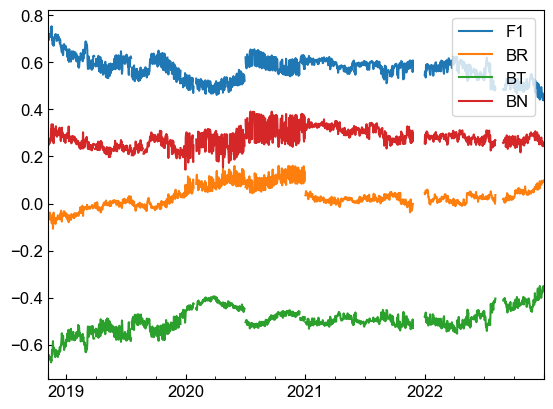

In [36]:
df_v2.resample("1d").mean().plot()

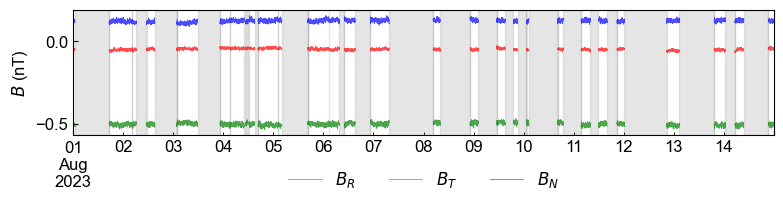

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create the plot with custom colors
fig, ax = plt.subplots(figsize=(8, 2.3))

df_v1[["BR", "BT", "BN"]]["2023-08-01":"2023-08-14"].plot(
    ax=ax, lw=0.5, alpha=0.7, color=["red", "green", "blue"]
)

# Detect and shade gaps
data_subset = df_v1["F1"]["2023-08-01":"2023-08-14"]
is_na = data_subset.isna()

gap_starts = []
gap_ends = []
in_gap = False

for timestamp, na_val in is_na.items():
    if na_val and not in_gap:
        gap_starts.append(timestamp)
        in_gap = True
    elif not na_val and in_gap:
        gap_ends.append(timestamp)
        in_gap = False

if in_gap:
    gap_ends.append(data_subset.index[-1])

# Add shaded rectangles for each gap
for start, end in zip(gap_starts, gap_ends):
    ax.axvspan(start, end, alpha=0.2, color="gray", zorder=0)

ax.set_ylabel("$B$ (nT)")

# Legend below plot
ax.legend(
    labels=["$B_R$", "$B_T$", "$B_N$"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    fontsize=12,
    frameon=False,
)

plt.tight_layout()
plt.savefig("../bg_figs/vgr_gaps.png", dpi=300, bbox_inches="tight")

Text(0, 0.5, 'B (nT)')

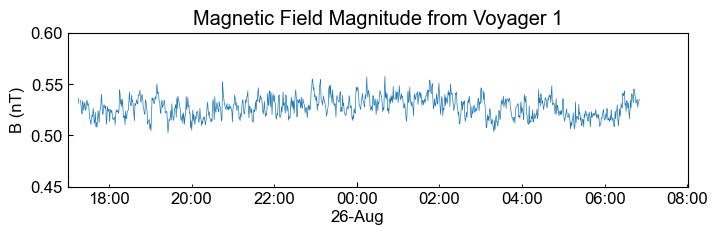

In [64]:
df_v1["F1"]["2023-08-25 17:00":"2023-08-26 08:00"].plot(
    figsize=(8, 2),
    title="Magnetic Field Magnitude from Voyager 1",
    lw=0.5,
    ylim=(0.45, 0.6),
)
plt.ylabel("B (nT)")

In [33]:
def overlay_missing_gap_analysis(
    data: Union[pd.Series, List],
    n_bins: int = 50,  # Increase bins to smooth the histogram
    xmax: int = None,
    title: str = "Gap Analysis: Frequency & Proportion of Data Missing",
    figsize: Tuple[int, int] = (10, 6),
    time_unit: str = "hours",
    resolution: int = 48,  # Data point resolution in seconds
    log_y: bool = True,  # Enable log scaling for better visualization
    smooth_proportion: bool = True,  # Smooth missing proportion line
    rolling_window: int = 5,  # Rolling window size for smoothing
    path: str = None
) -> None:
    """
    Create an overlayed histogram showing:
    1. Count of gaps per gap length (bars)
    2. Proportion of dataset missing due to each gap length (smoothed line plot)

    Parameters:
    -----------
    data : pd.Series or list
        The time series data with potential missing values (NaN or None)
    bins : int
        Number of bins for the histogram
    max_gap_length : int, optional
        Maximum gap length to consider
    title : str
        Title for the plot
    figsize : tuple
        Figure size (width, height) in inches
    time_unit : str
        Unit for time ('seconds', 'minutes', 'hours', 'days')
    resolution : int
        Number of seconds per data point (default: 48s)
    log_y : bool
        Apply log scale to the y-axis for better readability
    smooth_proportion : bool
        Apply smoothing to the missing proportion plot
    rolling_window : int
        Window size for smoothing (only used if smooth_proportion=True)

    Returns:
    --------
    None : Displays the combined histogram
    """
    # Convert to pandas Series if list is provided
    if isinstance(data, list):
        data = pd.Series(data)

    # Find missing values
    is_missing = data.isna()

    # If no missing values, return early
    if not is_missing.any():
        print("No missing values found in the data.")
        return

    # Detect contiguous missing value gaps
    padded = pd.concat(
        [pd.Series([False]), is_missing, pd.Series([False])]
    ).reset_index(drop=True)
    starts = padded[~padded.shift(1).astype(bool) & padded].index - 1
    ends = padded[padded & ~padded.shift(-1).astype(bool)].index - 1

    # Calculate lengths of contiguous missing intervals
    gap_lengths = ends - starts + 1

    # Compute histogram data for gap count
    gap_series = pd.Series(gap_lengths)
    gap_counts = gap_series.value_counts().sort_index()  # Frequency of each gap length

    # Compute missing proportion per gap length
    missing_proportions = (gap_counts * gap_counts.index) / len(data)

    # Smooth missing proportion if needed
    if smooth_proportion:
        missing_proportions = missing_proportions.rolling(
            rolling_window, min_periods=1
        ).mean()

    # Time conversion factors
    time_conversion = {
        "seconds": 1,
        "minutes": 1 / 60,
        "hours": 1 / 3600,
        "days": 1 / 86400,
    }

    if time_unit not in time_conversion:
        raise ValueError(
            f"Invalid time_unit: {time_unit}. Choose from {list(time_conversion.keys())}."
        )

    resolution_in_units = resolution * time_conversion[time_unit]

    # Prepare figure
    fig, ax1 = plt.subplots(figsize=figsize)

    if xmax:
        bins = np.linspace(0, xmax, num=n_bins + 1)
        ax1.set_xlim(0, xmax)
    else:
        bins=n_bins

    # Plot histogram for count of gaps
    ax1.hist(
        gap_lengths,
        bins,
        edgecolor="black",
        alpha=0.4,
        color="tab:blue",
        zorder=3
    )
    ax1.set_xlabel("Gap Length (# Points)")
    ax1.set_ylabel("Count of Gaps", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Apply log scale if needed
    if log_y:
        ax1.set_yscale("log")

    # Add secondary y-axis for proportion of dataset missing
    ax2 = ax1.twinx()
    ax2.plot(
        gap_counts.index,
        missing_proportions.cumsum(),
        color="tab:red",
        linestyle="-",
        linewidth=2,
        label="Cumulative Proportion of Dataset Missing",
    )
    ax2.set_ylabel("Cumulative % of Dataset Missing", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    # Add horizontal line at true overall missing proportion
    overall_missing = is_missing.sum() / len(data)

    ax2.axhline(
        overall_missing,
        color="tab:red",
        linestyle="--",
        linewidth=1,
        zorder=1,
    )
    # Annotate line with overall missing proportion
    ax2.text(
        0.98,
        overall_missing + 0.01,
        f"TOTAL MISSING FRACTION: {overall_missing*100:.1f}%",
        color="tab:red",
        ha="right",
        va="bottom",
        fontsize=10,
        transform=ax2.transAxes,
    )

    ax2.set_ylim(0, 1)
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))

    # Add grid
    # ax1.grid(axis="y", alpha=0.3)

    # Add secondary x-axis with time conversion
    def data_points_to_time(x):
        return x * resolution_in_units

    def time_to_data_points(x):
        return x / resolution_in_units

    ax3 = ax1.secondary_xaxis(
        "top", functions=(data_points_to_time, time_to_data_points)
    )
    ax3.set_xlabel(f"Gap Duration ({time_unit})")

    # Set title and align it properly
    ax1.text(
        0.05,
        0.95,
        title,
        transform=ax1.transAxes,
        fontsize=16,
        verticalalignment="top",
    )
    ax1.set_ylim(0.6,3e4)
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

    gaps_df = pd.DataFrame(
        {
            "Gap Length": gap_counts.index,
            "Gap Count": gap_counts.values,
            "Missing Proportion": missing_proportions.values,
        }
    )

    return gaps_df

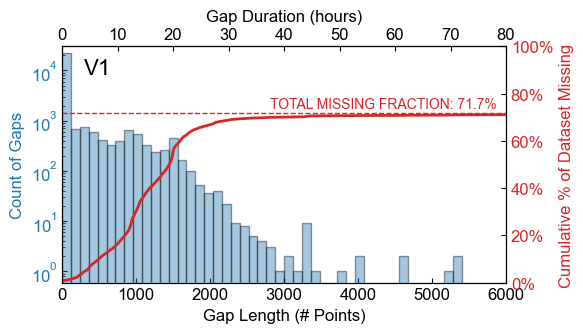

In [34]:
gaps_df = overlay_missing_gap_analysis(df_v1.BN, xmax=6000, time_unit="hours", title="V1", figsize=(6,3.5), path="../results/cleaning/gap_analysis_cdf_voyager1.png")

Shows distribution of gaps up to 80 hours (approximately 3.33 days). There are three larger gaps not shown, of length 3.6, 5.3, and 23.8 days, contributing an additional 0.4% missing.

In [15]:
42827*48/(60*60*24)

23.79277777777778

In [26]:
938*48/(60*60)

12.506666666666666

In [17]:
gaps_df

,Gap Length,Gap Count,Missing Proportion
0,1,15716,0.002156
1,2,2225,0.001383
2,3,2171,0.001220
3,4,343,0.000962
4,5,214,0.000799
...,...,...,...
1824,5310,1,0.000652
1825,5353,1,0.000689
1826,6547,1,0.000742
1827,9454,1,0.000874


In [24]:
15716+2225+2171

20112

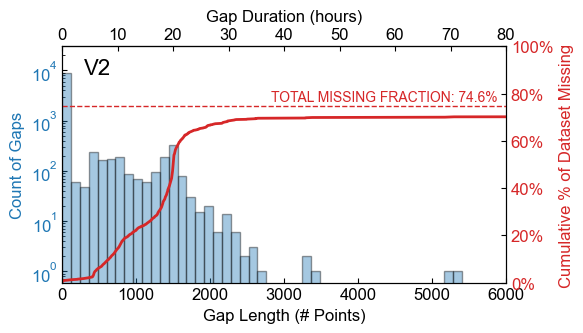

In [35]:
gaps_df = overlay_missing_gap_analysis(
    df_v2.BN,
    xmax=6000,
    time_unit="hours",
    title="V2",
    figsize=(6, 3.5),
    path="../results/cleaning/gap_analysis_cdf_voyager2.png",
)

Shows distribution of gaps up to 80 hours (approximately 3.33 days). There are three larger gaps not shown, of length 8.3, 24.4, and 35.1 days, contributing an additional 2% missing

In [19]:
14851*48/(60*60*24)

8.250555555555556

In [20]:
0.00969579856536378 + 0.005312106572976138 + 0.002341750841750842

0.01734965598009076

In [21]:
gaps_df

,Gap Length,Gap Count,Missing Proportion
0,1,6783,0.002482
1,2,784,0.001528
2,3,666,0.001263
3,4,118,0.000990
4,5,76,0.000820
...,...,...,...
1050,5174,1,0.001302
1051,5296,1,0.001495
1052,14851,1,0.002342
1053,43874,1,0.005312


In [27]:
428*48/(60*60)

5.706666666666667

In [22]:
def contiguous_missing_proportion_histogram(
    data: Union[pd.Series, List],
    bins: int = 10,
    xmax: int = None,
    title: str = "Proportion of Dataset Missing by Gap Length",
    figsize: Tuple[int, int] = (10, 6),
    time_unit: str = "seconds",
    resolution: int = 48,  # Time per data point in seconds (default: 48s)
) -> pd.Series:
    """
    Create a histogram showing the proportion of the dataset lost due to gaps of each length.

    Parameters:
    -----------
    data : pd.Series or list
        The time series data with potential missing values (NaN or None)
    bins : int
        Number of bins for the histogram
    max_gap_length : int, optional
        Maximum gap length to consider for the histogram
    title : str
        Title for the plot
    figsize : tuple
        Figure size (width, height) in inches
    time_unit : str
        Unit for time ('seconds', 'minutes', 'hours', 'days')
    resolution : int
        Number of seconds per data point (default: 48s)

    Returns:
    --------
    pd.Series : Proportion of dataset missing due to each gap length
    """
    # Convert to pandas Series if list is provided
    if isinstance(data, list):
        data = pd.Series(data)

    # Find missing values
    is_missing = data.isna()

    # If no missing values, return early
    if not is_missing.any():
        print("No missing values found in the data.")
        return pd.Series()

    # Detect contiguous missing value gaps
    padded = pd.concat(
        [pd.Series([False]), is_missing, pd.Series([False])]
    ).reset_index(drop=True)
    starts = padded[~padded.shift(1).astype(bool) & padded].index - 1
    ends = padded[padded & ~padded.shift(-1).astype(bool)].index - 1

    # Calculate lengths of contiguous missing intervals
    gap_lengths = ends - starts + 1

    # Compute missing fraction per gap length
    gap_series = pd.Series(gap_lengths)
    gap_proportions = gap_series.groupby(gap_series).sum() / len(data)

    # Time conversion factors
    time_conversion = {
        "seconds": 1,
        "minutes": 1 / 60,
        "hours": 1 / 3600,
        "days": 1 / 86400,
    }

    if time_unit not in time_conversion:
        raise ValueError(
            f"Invalid time_unit: {time_unit}. Choose from {list(time_conversion.keys())}."
        )

    # Convert resolution from seconds to the chosen time unit
    resolution_in_units = resolution * time_conversion[time_unit]

    # Prepare figure
    fig, ax = plt.subplots(figsize=figsize)

    if xmax:
        ax.set_xlim(0, xmax)

    # Plot bar chart
    ax.bar(gap_proportions.index, gap_proportions, edgecolor="black", alpha=0.7)

    # Add labels and title
    ax.set_xlabel("Number of Contiguous Missing Values")
    ax.set_ylabel("Proportion of Dataset Missing")
    ax.set_title(title)

    # Use log scale only if needed
    # if gap_proportions.max() / gap_proportions.min() > 100:
    #     ax.set_yscale("log")

    # Add grid for better readability
    ax.grid(axis="y", alpha=0.3)

    # Add secondary x-axis with gap length converted to time units
    def data_points_to_time(x):
        return (
            x * resolution_in_units
        )  # Convert missing data points to chosen time unit

    def time_to_data_points(x):
        return x / resolution_in_units  # Convert time back to missing data points

    ax2 = ax.secondary_xaxis(
        "top", functions=(data_points_to_time, time_to_data_points)
    )
    ax2.set_xlabel(f"Time ({time_unit})")

    plt.tight_layout()
    plt.savefig(f"../results/cleaning/gap_analysis_pdf_voyager2.png", dpi=300)
    plt.show()

In [23]:
contiguous_missing_proportion_histogram(df.BN, xmax=4000, time_unit="hours", title="Voyager 2 LISM: Missing Data Proportion by Gap Length")

NameError: name 'df' is not defined

In [ ]:
gaps_df["Gap Length (hours)"] = gaps_df["Gap Length"] * 48 / 3600
gaps_df

,Gap Length,Gap Count,Missing Proportion,Gap Length (hours)
0,1,6783,0.002482,0.013333
1,2,784,0.001528,0.026667
2,3,666,0.001263,0.040000
3,4,118,0.000990,0.053333
4,5,76,0.000820,0.066667
...,...,...,...,...
1050,5174,1,0.001302,68.986667
1051,5296,1,0.001495,70.613333
1052,14851,1,0.002342,198.013333
1053,43874,1,0.005312,584.986667


In [ ]:
# Get the combined missing proportion from gaps between 19 and 20 hours
def find_missing_proportion_in_range(a,b):
    missing_prop = gaps_df.loc[gaps_df["Gap Length (hours)"].between(a,b), "Missing Proportion"].sum()
    print(f"Missing proportion for gaps between {a} and {b} hours: {missing_prop:.2%}")

find_missing_proportion_in_range(18,22)
find_missing_proportion_in_range(10,14)
find_missing_proportion_in_range(0,4)
find_missing_proportion_in_range(4,18)

Missing proportion for gaps between 18 and 22 hours: 29.60%
Missing proportion for gaps between 10 and 14 hours: 9.09%
Missing proportion for gaps between 0 and 4 hours: 1.73%
Missing proportion for gaps between 4 and 18 hours: 30.85%


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

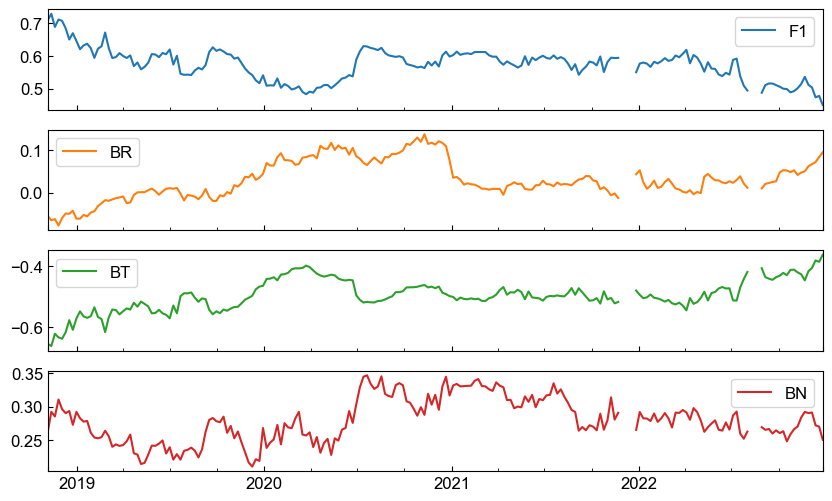

In [ ]:
df.resample("7D").mean().plot(subplots=True, figsize=(10, 6))